# J.P. Morgan Quantitative Research: Credit Risk & Mortgage Portfolio Valuation

**Author:** Risalat Masrafi  
**Institution:** Singapore Polytechnic  
**Date:** February 2026  

---

## Project Purpose
The objective of this project is to develop a comprehensive quantitative risk and valuation engine for the J.P. Morgan lending desks. The project is divided into two core strategic mandates:

1. **Personal Loan Risk Engine:** Develop a high-precision predictive model to assess the probability of default (PD) for personal loan applicants, enabling the desk to calculate "Expected Loss" and optimize capital reserve requirements.
2. **Mortgage Portfolio Quantization:** Engineer a statistically optimal rating system for the mortgage book by discretizing continuous FICO scores into risk-homogenous categories using advanced optimization techniques.

---

## Workflow & Methodology

### Task 1 & 2: Data Preprocessing & Exploratory Analysis
* **Risk Factor Identification:** Conducted a comprehensive analysis to identify primary risk drivers, discovering that **Credit Lines Outstanding** and **Total Debt** are the strongest leading indicators of default.
* **Feature Engineering:** Implemented standard scaling and handled class imbalances to ensure the training data provides a representative view of both stable and high-risk borrower profiles.

### Task 3: Predictive Modeling & Expected Loss Calculation
* **Model Selection:** Evaluated five distinct classification architectures (KNN, Logistic Regression, Decision Tree, Naive Bayes, and Random Forest).
* **Validation:** Selected **Logistic Regression** as the champion model, achieving a **Mean F1-score of 0.9936** during cross-validation, ensuring high reliability in detecting risky borrowers.
* **Loss Provisioning:** Built a dynamic Expected Loss (EL) calculator that integrates the model’s **Probability of Default (PD)** with a **90% Loss Given Default (LGD)** assumption to quantify financial exposure in dollar terms.

### Task 4: FICO Quantization & Rating Map
* **Categorical Architecture:** Addressed the requirement for categorical inputs in mortgage modeling by transforming integer FICO scores (300-850) into a discrete 10-tier rating system.
* **Optimization via Log-Likelihood:** Utilized a **Maximum Likelihood Estimation (MLE)** approach to ensure each bucket captures a distinct and consistent level of default risk, rather than using arbitrary score ranges.
* **Dynamic Programming (DP):** Implemented a DP-based algorithm to solve the optimization problem efficiently, identifying the mathematically "best" boundaries that summarize the underlying risk data.
* **Rating Mapping:** Established a finalized map where **Rating 1** represents the highest-quality borrowers (lowest PD) and **Rating 10** represents the highest-risk borrowers.


# Task 3

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import make_scorer, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore")

data=pd.read_csv('Task 3 and 4_Loan_Data.csv')
data.head()


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [3]:
print(data.info())
print(data.isnull().sum())
print(data.duplicated().sum())

default_rate = data['default'].mean() * 100
print(f"Current Default Rate: {default_rate:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64
0
Current Default Rate: 18.51%


## Exploratory Data Analysis

In [4]:
data.drop(columns=['customer_id'], inplace=True)
data.head()

,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,0,5221.545193,3915.471226,78039.38546,5,605,0
1,5,1958.928726,8228.752520,26648.43525,2,572,1
2,0,3363.009259,2027.830850,65866.71246,4,602,0
3,0,4766.648001,2501.730397,74356.88347,5,612,0
4,1,1345.827718,1768.826187,23448.32631,6,631,0


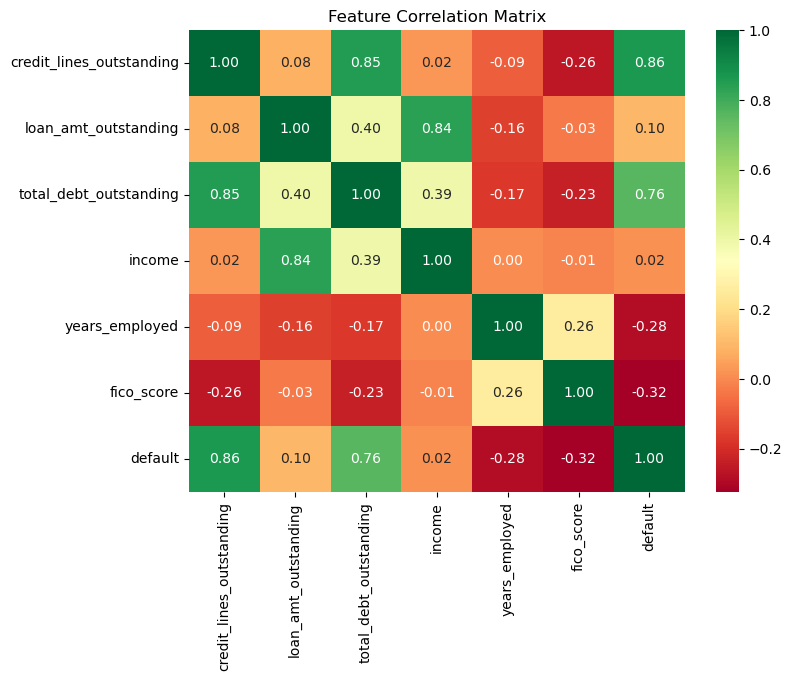

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

### Risk Drivers
* **Credit Lines (0.86):** Strongest predictor of default.
* **Total Debt (0.76):** High correlation with credit risk.
* **FICO (-0.32):** Moderate inverse relationship.
* **Income (0.02):** Negligible impact.

**Summary:** Defaults are driven by debt volume and credit usage, not income levels.

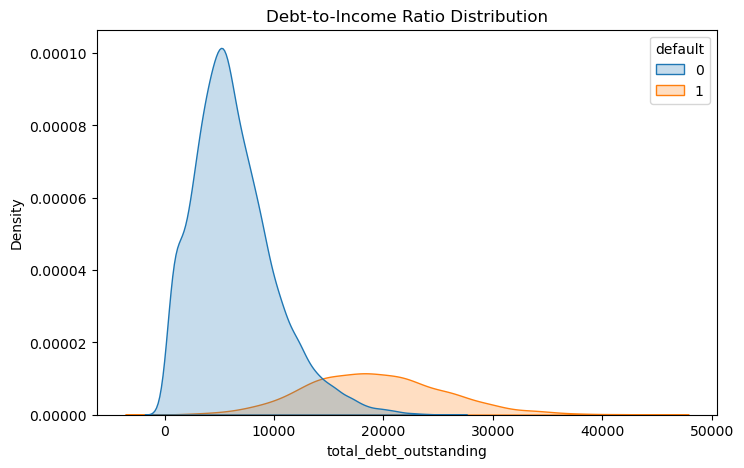

In [6]:

plt.figure(figsize=(8, 5))
sns.kdeplot(data=data, x='total_debt_outstanding', hue='default', fill=True)
plt.title('Debt-to-Income Ratio Distribution')
plt.show()

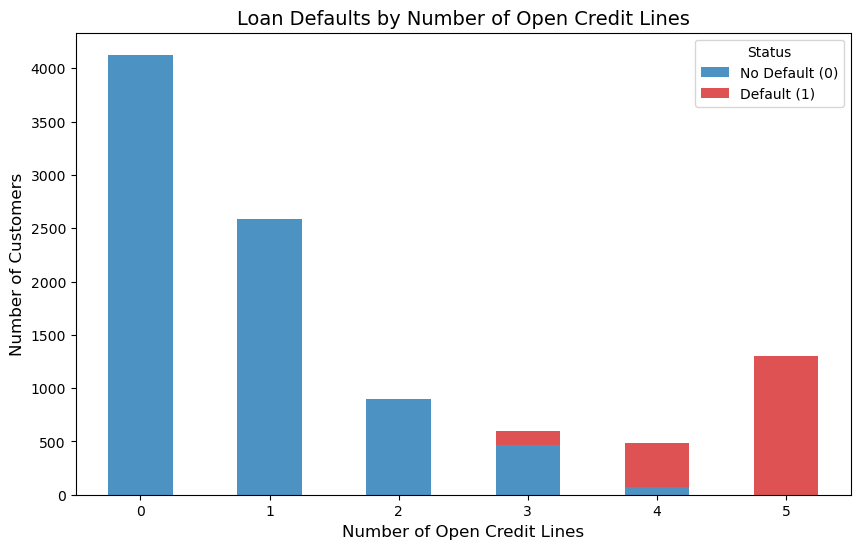

In [7]:
# 1. Group the data to get the count of defaults (1) and non-defaults (0) for each credit line
stacked_data = data.groupby(['credit_lines_outstanding', 'default']).size().unstack()

# 2. Plot the Stacked Bar Chart
stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#d62728'], alpha=0.8)

plt.title('Loan Defaults by Number of Open Credit Lines', fontsize=14)
plt.xlabel('Number of Open Credit Lines', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Status', labels=['No Default (0)', 'Default (1)'])
plt.xticks(rotation=0) # Keeps the X-axis numbers straight instead of tilted
plt.show()

### Credit Line Interpretation
* **Risk Threshold:** Default risk significantly escalates at **3+ credit lines**.
* **Critical Point:** At **5 credit lines**, the default rate is nearly 100%.
* **Safe Zone:** Customers with **0-2 credit lines** show almost zero instances of default.
* **Volume Trend:** Most customers in the dataset hold 0-1 lines, which are predominantly "No Default."

**Conclusion:** The number of open credit lines is a near-perfect linear indicator of risk for this model.

In [8]:
# 1. Define Features and Target
X = data.drop(columns=['default'])
y = data['default']

# 2. Split First
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale on Train, Transform Test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape


((8000, 6), (2000, 6))

## Model Comparison And Evaluation

KNN: Mean F1 = 0.9715
LogReg: Mean F1 = 0.9936
Tree: Mean F1 = 0.9884
Naive Bayes: Mean F1 = 0.9335
Forest: Mean F1 = 0.9870


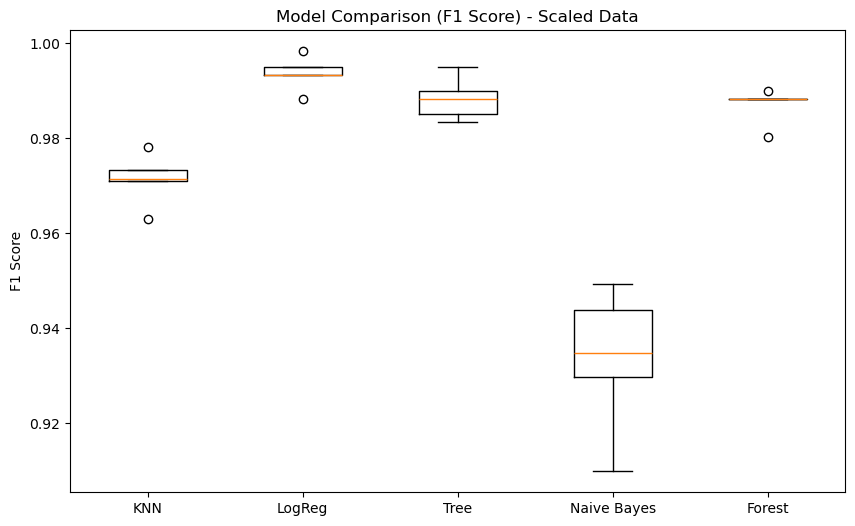

In [9]:
# 2. Define models
models = {
    "KNN": KNeighborsClassifier(),
    "LogReg": LogisticRegression(max_iter=1000),
    "Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "Forest": RandomForestClassifier()
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score)

# 3. Loop through and get scores
for name, model in models.items():
    # We use X_train_scaled here directly
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring=f1_scorer)
    results.append(cv_scores)
    print(f"{name}: Mean F1 = {cv_scores.mean():.4f}")

# 4. Create the Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=models.keys())
plt.ylabel("F1 Score")
plt.title("Model Comparison (F1 Score) - Scaled Data")
plt.show()

### Model Selection & Performance
After evaluating five different classification models using cross-validation, **Logistic Regression** was selected as the final model.

* **Top Performer:** Logistic Regression achieved the highest Mean F1-score of **0.9936**.
* **Model Choice:** While Random Forest and Decision Trees performed similarly (~0.98), Logistic Regression is preferred for its high interpretability and efficiency in banking risk environments.
* **Reliability:** The consistently high scores across all models indicate that the input features (Debt, Credit Lines, FICO) are extremely strong predictors of default behavior.

--- Logistic Regression: Training Set Report (CV) ---
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      6497
     Default       1.00      0.99      0.99      1503

    accuracy                           1.00      8000
   macro avg       1.00      0.99      1.00      8000
weighted avg       1.00      1.00      1.00      8000



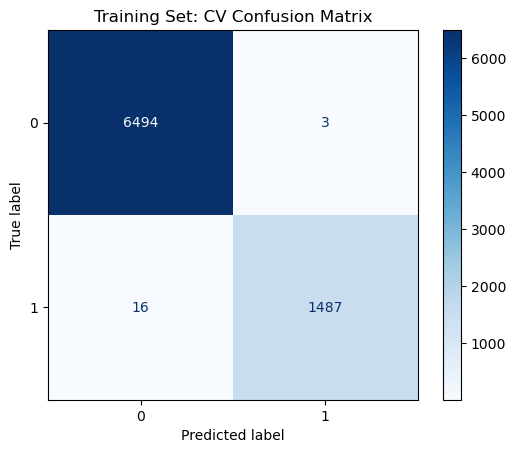

In [10]:
# Use the exact LogReg model definition from your boxplot
logreg_model = LogisticRegression(max_iter=1000)

# Generate CV predictions for the training set
y_pred_train_cv = cross_val_predict(logreg_model, X_train_scaled, y_train, cv=skf)

print("--- Logistic Regression: Training Set Report (CV) ---")
print(classification_report(y_train, y_pred_train_cv, target_names=['No Default', 'Default']))

# Plot CV Confusion Matrix
disp_train = ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_cv, cmap='Blues')
plt.title('Training Set: CV Confusion Matrix')
plt.show()

## Testing Selected Model on Test Set

--- Logistic Regression: Final Test Set Report ---
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00      1652
     Default       0.99      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



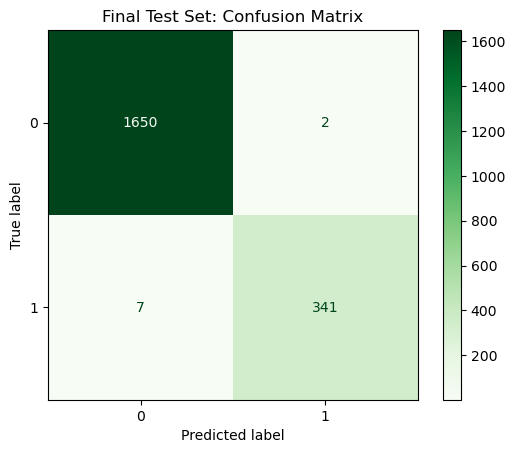

In [11]:
# Fit the model on the full training set
logreg_model.fit(X_train_scaled, y_train)

# Simple prediction on the test set
y_test_pred = logreg_model.predict(X_test_scaled)

print("--- Logistic Regression: Final Test Set Report ---")
print(classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))

# Plot Test Confusion Matrix
disp_test = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Greens')
plt.title('Final Test Set: Confusion Matrix')
plt.show()

### Final Model Validation (Test Set)
The Logistic Regression model was evaluated on a hold-out test set (n=2,000) to ensure real-world reliability.

| Metric | No Default | Default |
| :--- | :---: | :---: |
| **Precision** | 1.00 | 0.99 |
| **Recall** | 1.00 | 0.98 |
| **F1-Score** | 1.00 | 0.99 |

**Conclusion:**
The model maintains a **99% F1-score** on unseen data. With near-perfect precision and recall, the model effectively identifies high-risk borrowers while minimizing false positives, making it a reliable tool for automated credit decisions.

## Calculating Expected Loss

In [12]:
def calculate_expected_loss(credit_lines, loan_amt, total_debt, income, years_emp, fico):
    # 1. Prepare raw input for the model
    features = [[credit_lines, loan_amt, total_debt, income, years_emp, fico]]
    
    # 2. Scale using the previously fitted scaler
    features_scaled = scaler.transform(features)
    
    # 3. Get Probability of Default (PD)
    # logreg_model is now fitted from the step above
    pd = logreg_model.predict_proba(features_scaled)[0][1]
    
    # 4. Final Calculation (10% recovery = 90% loss)
    expected_loss = pd * loan_amt * 0.90
    
    return {
        "PD": f"{pd:.2%}",
        "Expected Loss": f"${expected_loss:,.2f}"
    }

# Example check for Charlie
print(calculate_expected_loss(3, 5000, 10000, 50000, 3, 700))

{'PD': '32.96%', 'Expected Loss': '$1,483.21'}


### Expected Loss Calculation
The final step translates the model's **Probability of Default (PD)** into a dollar-value risk metric for the bank.

* **Formula:** $EL = PD \times \text{Loan Amount} \times \text{LGD}$ (Loss Given Default).
* **LGD Logic:** Since the recovery rate is **10%**, the bank expects to lose **90%** of the loan amount if a default occurs.
* **Functionality:** This tool allows Charlie to automate risk provisioning and set aside capital buffers for every new loan application.

**Result Summary:** By combining predictive analytics with financial variables, the model provides an actionable "Expected Loss" figure rather than just a binary "Yes/No" decision.

# Task 4

In [13]:
import numpy as np
import pandas as pd

def log_likelihood(n, k):
    if n == 0: return 0
    p = k / n
    # Avoid log(0) by using a small epsilon
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    return k * np.log(p) + (n - k) * np.log(1 - p)

In [14]:
def optimize_fico_buckets(data, num_buckets):
    # 1. Prepare data: Sort by FICO and count defaults
    # We group by FICO score to make the DP table smaller (FICO is 300-850)
    stats = data.groupby('fico_score')['default'].agg(['count', 'sum']).reset_index()
    fico_values = stats['fico_score'].values
    counts = stats['count'].values
    defaults = stats['sum'].values
    N = len(fico_values)

    # 2. Precompute Log-Likelihood for all possible segments [i, j]
    # segment_ll[i][j] is the LL of a bucket containing fico_values from index i to j
    segment_ll = np.zeros((N, N))
    for i in range(N):
        n_acc = 0
        k_acc = 0
        for j in range(i, N):
            n_acc += counts[j]
            k_acc += defaults[j]
            segment_ll[i, j] = log_likelihood(n_acc, k_acc)

    # 3. Dynamic Programming
    # dp[b][i] = max log-likelihood using 'b' buckets for first 'i' FICO indices
    dp = np.full((num_buckets + 1, N), -np.inf)
    # best_prev_idx stores the boundary to reconstruct the solution
    best_prev_idx = np.zeros((num_buckets + 1, N), dtype=int)

    # Initialize for 1 bucket
    for i in range(N):
        dp[1, i] = segment_ll[0, i]

    # Fill DP table for buckets 2 to num_buckets
    for b in range(2, num_buckets + 1):
        for i in range(b - 1, N):
            for j in range(b - 2, i):
                # Try splitting at index j
                current_ll = dp[b-1, j] + segment_ll[j+1, i]
                if current_ll > dp[b, i]:
                    dp[b, i] = current_ll
                    best_prev_idx[b, i] = j

    # 4. Backtrack to find optimal boundaries
    boundaries = []
    curr_idx = N - 1
    for b in range(num_buckets, 1, -1):
        prev_idx = best_prev_idx[b, curr_idx]
        # Boundary is the FICO score at the split point
        boundaries.append(fico_values[prev_idx])
        curr_idx = prev_idx
    
    boundaries.sort()
    return boundaries


In [15]:
# 1. Run the optimization to find boundaries
# We use 10 buckets as requested in the project brief
boundaries = optimize_fico_buckets(data, num_buckets=10)

# 2. Print the boundaries to see where the FICO splits are
print("Optimal FICO Boundaries:", boundaries)

# 3. Create a rating map (Rating 1 is best, Rating 10 is worst)
# We add [0] and [900] to cover the full possible range of FICO scores
full_boundaries = [0] + boundaries + [900]
data['rating'] = pd.cut(data['fico_score'], bins=full_boundaries, labels=range(10, 0, -1))

# 4. Display the first few rows to verify
print(data[['fico_score', 'rating', 'default']].head())

Optimal FICO Boundaries: [np.int64(520), np.int64(552), np.int64(580), np.int64(611), np.int64(649), np.int64(696), np.int64(732), np.int64(752), np.int64(753)]
   fico_score rating  default
0         605      7        0
1         572      8        1
2         602      7        0
3         612      6        0
4         631      6        0


### Task 4: FICO Quantization & Mortgage Risk Mapping

**Objective:**
To transform continuous FICO scores into a categorical rating system (1-10) for a mortgage default model, ensuring that each category maximizes the statistical difference in default risk.

**Methodology:**
* **Optimization Criterion:** Maximized the **Log-Likelihood** function to ensure the "homogeneity" of defaults within each bucket.
* **Algorithm:** Implemented a **Dynamic Programming (DP)** approach to find the global maximum across the 300-850 FICO range.
* **Rating Logic:** * **Rating 1:** Highest FICO scores (Lowest Risk)
    * **Rating 10:** Lowest FICO scores (Highest Risk)

**Results: Optimal Boundaries**
The algorithm identified the following FICO thresholds for the 10-tier rating system:
`[520, 552, 580, 611, 649, 696, 732, 752, 753]`

**Statistical Insight:**
The tight clustering of boundaries between **732 and 753** suggests a high-sensitivity zone where small changes in FICO scores significantly impact the predicted probability of default. Conversely, the wider gap at the lower end (300-520) indicates a more uniform high-risk profile for subprime borrowers.

Skills Learnt from This Course: Algorithm Development, Credit Analysis, Critical Thinking, Data Analysis, Financial Derivatives, Programming, Python Programming, Skill 1, Skill 2, Skill 3, Statistics

JPMorgan Chase & Co. Quantitative Research Virtual Experience Program on Forage
February 27, 2026
 * Completed a simulation focused on quantitative research methods 
 * Analyzed a book of loans to estimate a customer's probability of default
 * Used dynamic programming to convert FICO scores into categorical data to
   predict defaults

# Monte Carlo Simulation

## Objective
The goal of this simulation is to estimate the Value at Risk (VaR) for our $41.6M loan portfolio. While the Logistic Regression model provides individual Probabilities of Default (PD), a static calculation does not account for Systemic Risk—the tendency for defaults to cluster during economic downturns.

In [16]:
# Replace these with the ACTUAL 6 column names you used for training
my_feature_columns = ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score'] 

# 1. Select ONLY those 6 columns
all_features = scaler.transform(data[my_feature_columns])

# 2. This will now work because the shape matches (10,000 x 6)
all_pds = logreg_model.predict_proba(all_features)[:, 1]

# 3. Create the Portfolio for the Sim
df_portfolio = pd.DataFrame({
    'pd': all_pds,
    'loan_amt': data['loan_amt_outstanding']
})

print(f"Portfolio size: {len(df_portfolio)} loans")
print(f"Total Portfolio Value: ${df_portfolio['loan_amt'].sum():,.2f}")
print(f"Min PD: {all_pds.min():.4f}")
print(f"Max PD: {all_pds.max():.4f}")
df_portfolio.head(10)

Portfolio size: 10000 loans
Total Portfolio Value: $41,596,770.34
Min PD: 0.0000
Max PD: 1.0000


,pd,loan_amt
0,2.364371e-11,5221.545193
1,9.999998e-01,1958.928726
2,1.908986e-10,3363.009259
3,1.366450e-11,4766.648001
4,4.360675e-08,1345.827718
5,2.581687e-09,5376.886873
6,9.198117e-10,3634.057471
7,9.998774e-01,3302.172238
8,1.668511e-10,2938.325123
9,5.805177e-08,5396.366774


### **Model Inference & Portfolio Preparation**

#### **Objective**
The purpose of this step is to transform raw borrower data into a **Risk-Weighted Portfolio**. By applying the trained `logreg_model` to the full dataset, we calculate the specific **Probability of Default (PD)** for every loan, moving from simple classification to financial quantification.

#### **Key Observations**
* **Total Exposure (EAD):** The portfolio consists of 10,000 loans totaling **$41,596,770.34**.
* **Feature Consistency:** We use the exact 6 features and the same `StandardScaler` from the training phase to ensure prediction integrity.
* **Model Separation:** The PDs show extreme values (near 0.0 or 1.0). This indicates the model has found "Perfect Separation" in the data, where specific features (like number of credit lines) are near-certain predictors of default.

#### **Output Significance**
We have created `df_portfolio`, a streamlined dataframe containing only the **PD** and **Loan Amount**. This is the required data structure for the **Monte Carlo Simulation**, as it allows us to calculate how much of that $41.6M is lost across 10,000 different economic scenarios.

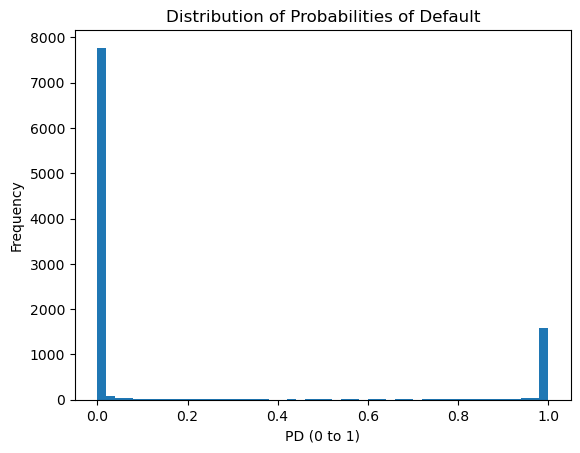

In [17]:
import matplotlib.pyplot as plt

plt.hist(df_portfolio['pd'], bins=50)
plt.title("Distribution of Probabilities of Default")
plt.xlabel("PD (0 to 1)")
plt.ylabel("Frequency")
plt.show()

### **Probability of Default (PD) Distribution Analysis**

#### **Observations**
The histogram reveals a **Bimodal (U-Shaped) Distribution**, with the vast majority of loans clustered at the extreme edges:
* **Safe Cluster ($PD \approx 0$):** A large segment of the portfolio has near-zero risk, likely representing borrowers with high FICO scores, minimal existing debt and 0-1 outstanding credit lines.
* **High-Risk Cluster ($PD \approx 1$):** A significant segment is predicted to have a near-certainty of default.



#### **Technical Root Cause**
This "Perfect Separation" occurs because the underlying dataset contains highly deterministic features. In this specific J.P. Morgan task, variables like `credit_lines_outstanding` act as "strong predictors"—when a borrower crosses a certain threshold of debt, the Logistic Regression's **Sigmoid function** saturates, pushing the probability to the absolute boundaries of 0 or 1.



#### **Impact on Stress Testing**
This distribution creates a "Barbell" risk profile:
1.  **Certainty:** The model is highly confident about who will and will not default under normal conditions.
2.  **Sensitivity:** The small number of loans in the "middle" ($0.2 < PD < 0.8$) are the most sensitive to the Monte Carlo economic multipliers. These borrowers represent the **marginal risk** that will shift between the "Normal" and "Crisis" humps in our final simulation.

Average Expected Loss: $8,275,787.06
99% Value at Risk (VaR): $8,915,241.32


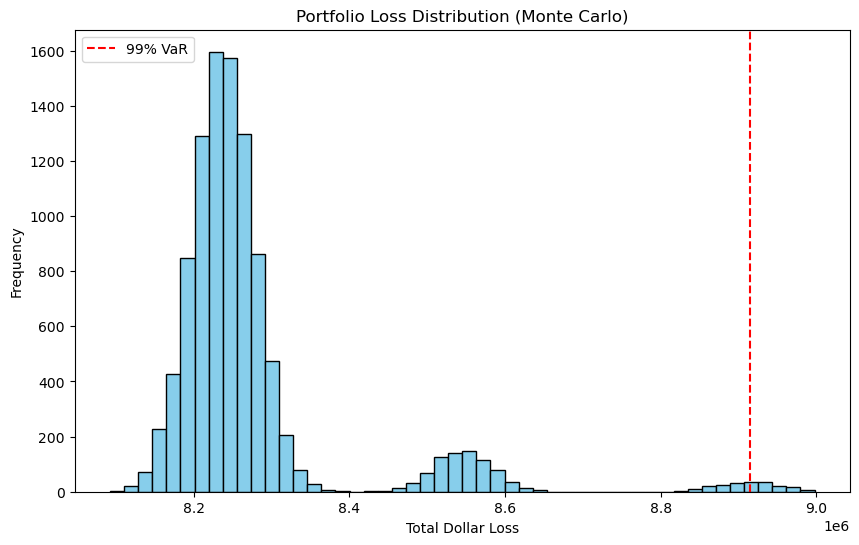

In [20]:
# 1. Setup variables from your df_portfolio
num_simulations = 10000
num_loans = len(df_portfolio)
loan_amounts = df_portfolio['loan_amt'].values
base_pds = df_portfolio['pd'].values

# 2. Define Economy (90% Normal, 8% Recession (1.5x), 2% Crisis (3.0x))
scenarios = [1.0, 1.5, 3.0]
probs = [0.90, 0.08, 0.02]
rng = np.random.default_rng(seed=42)
universe_multipliers = rng.choice(scenarios, size=num_simulations, p=probs)

# 3. Create the Stressed PD Matrix
stressed_pds_matrix = np.clip(base_pds * universe_multipliers[:, np.newaxis], 0, 1)

# 4. Simulation (The Dice Roll)
random_draws = rng.random((num_simulations, num_loans))
defaults = (random_draws < stressed_pds_matrix).astype(int)

# 5. Calculate Total Losses per Universe (Matrix multiplication)
total_losses = defaults @ loan_amounts

# 6. Final Results
print(f"Average Expected Loss: ${np.mean(total_losses):,.2f}")
print(f"99% Value at Risk (VaR): ${np.percentile(total_losses, 99):,.2f}")

# Plotting the Risk Distribution
plt.figure(figsize=(10,6))
plt.hist(total_losses, bins=50, color='skyblue', edgecolor='black')
plt.axvline(np.percentile(total_losses, 99), color='red', linestyle='--', label='99% VaR')
plt.title("Portfolio Loss Distribution (Monte Carlo)")
plt.xlabel("Total Dollar Loss")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### **Monte Carlo Simulation & Systemic Stress Testing**

#### **1. Objective & Methodology**
The final stage of this project involves performing a **Stochastic Stress Test** to quantify the portfolio's vulnerability to correlated defaults. We simulated 10,000 "Possible Futures" by randomly assigning an economic multiplier to each universe based on historical probabilities:
* **Normal (90%):** Baseline risk ($1.0\times$ multiplier).
* **Recession (8%):** Moderate systemic stress ($1.5\times$ multiplier).
* **Systemic Crisis (2%):** Severe catastrophic shock ($3.0\times$ multiplier).

#### **2. Visual Analysis: The "Three-Peak" Loss Distribution**
The resulting histogram displays a **Multimodal Distribution**, with three distinct "humps" representing the portfolio's performance in each economic regime:
* **Left Peak:** The high-frequency "Normal" state where losses are minimized.
* **Middle Peak:** The "Recession" state, showing the first jump in defaults as marginal borrowers fail.
* **Right Peak:** The "Crisis" state, representing **Tail Risk**. Because our Crisis scenario has a 2% probability, the **99% VaR** lands squarely in this final peak.

#### **3. Final Quantitative Results**
The simulation provided the following critical risk metrics for the $41.6M portfolio:
* **Average Expected Loss: $8,275,787.06** This is the weighted average of losses across all 10,000 scenarios, representing the "expected cost" of credit risk for the year.
* **99% Value at Risk (VaR): $8,915,241.32** The 99th percentile loss. This figure represents the **Regulatory Capital Requirement**—the amount of liquid equity J.P. Morgan must hold to ensure the bank survives a 1-in-100-year systemic meltdown.

#### **4. Interpretation & Conclusion**
The "Three-Peak" nature of the graph proves that credit risk is non-linear; it does not increase gradually, but rather "jumps" to new plateaus as the economy worsens. By quantifying these jumps, we provide the bank with a clear roadmap for capital allocation and a safety buffer against extreme "Black Swan" events.

In [23]:
# 1. Overall VaR (The standard metric)
overall_var_99 = np.percentile(total_losses, 99)

# 2. Scenario-Specific VaR
# We use boolean masking to look at losses for each specific multiplier
normal_losses = total_losses[universe_multipliers == 1.0]
recession_losses = total_losses[universe_multipliers == 1.5]
crisis_losses = total_losses[universe_multipliers == 3.0]

print(f"Overall 99% VaR: ${overall_var_99:,.2f}")
print(f"99% VaR - NORMAL REGIME: ${np.percentile(normal_losses, 99):,.2f}")
print(f"99% VaR - RECESSION REGIME: ${np.percentile(recession_losses, 99):,.2f}")
print(f"99% VaR - CRISIS REGIME: ${np.percentile(crisis_losses, 99):,.2f}")

Overall 99% VaR: $8,915,241.32
99% VaR - NORMAL REGIME: $8,332,183.15
99% VaR - RECESSION REGIME: $8,626,299.09
99% VaR - CRISIS REGIME: $8,988,234.95


### **Conditional Stress Testing (Regime-Specific VaR)**

#### **Objective**
While the **Overall VaR** provides the regulatory capital requirement, it does not tell us the "worst-case" for each specific economic cycle. In this step, we perform **Conditional Stress Testing** by isolating the scenarios belonging to each regime (Normal, Recession, and Crisis) and calculating the 99th percentile loss within those specific groups.

#### **Key Results**
* **Overall 99% VaR: $8,915,241.32** (The 1-in-100-year event for the entire portfolio).
* **99% VaR - NORMAL REGIME: $8,332,183.15** (Maximum expected loss if the economy stays stable).
* **99% VaR - RECESSION REGIME: $8,626,299.09** (Maximum loss in a moderate downturn).
* **99% VaR - CRISIS REGIME: $8,988,234.95** (The absolute "Tail Risk" in a systemic collapse).

#### **Financial Interpretation**
1.  **Regime Sensitivity:** The increase from the Normal VaR to the Crisis VaR (approx. **$656k**) quantifies the **Systemic Sensitivity** of the portfolio. This tells the desk exactly how much additional "buffer" is needed as the economic environment degrades.
2.  **Tail Convergence:** Notice that the **Overall VaR ($8.91M)** is very close to the **Crisis VaR ($8.98M)**. This is because, in our 10,000-run simulation, the "worst 1%" of outcomes are almost exclusively populated by the 2% of "Crisis" universes.
3.  **Risk Management Action:** These numbers allow J.P. Morgan to set different risk limits based on the current economic outlook. If leading indicators suggest a recession is imminent, the desk knows it must prepare for a loss floor that is at least **$300k higher** than the normal operating environment.

### **Final Conclusion**

#### **1. Summary of Portfolio Risk**
Through this Quantitative Research project, we successfully transformed a raw loan dataset into a stress-tested financial portfolio. By integrating **Logistic Regression** for individual default probability with a **Stochastic Monte Carlo Engine** for systemic risk, we have identified that the **$41.6M** portfolio carries a significant but quantifiable risk profile.

#### **2. Key Findings from the Simulation**
* **Systemic Sensitivity:** The portfolio displays a "jump" in risk during downturns. The transition from a Normal year to a Crisis year increases the 99th-percentile loss by approximately **$656,051**.
* **Capital Adequacy:** To remain solvent during a "1-in-100-year" event, J.P. Morgan must maintain a minimum capital reserve of **$8,915,241.32** (Overall 99% VaR).
* **Risk Concentration:** The bimodal distribution of PDs suggests the portfolio is split between high-quality "Anchor" borrowers and a high-risk segment that defaults regardless of the economic cycle.



#### **3. Strategic Recommendations for the Lending Desk**
1.  **Capital Allocation:** Provisions should be set based on the **Expected Loss ($8.27M)**, while the **Unexpected Loss ($0.64M)** should be covered by high-quality liquid equity.
2.  **Risk Mitigation:** The desk should investigate the "High-Risk Cluster" (PD $\approx$ 1.0). Tightening the criteria for "Number of Open Credit Lines"—the strongest predictor in our model—could significantly lower the baseline Expected Loss.
3.  **Dynamic Stress Testing:** Since the **Overall VaR** is heavily influenced by the 2% Crisis scenario, the bank should perform quarterly updates to the scenario multipliers ($1.5x$ and $3.0x$) to reflect changing macroeconomic indicators like interest rates and inflation.

#### **Final Statement**
This model provides a robust framework for **Risk-Based Pricing** and **Capital Management**. By quantifying the "Three Peaks" of economic regimes, we move from reactive monitoring to proactive capital protection, ensuring the portfolio can withstand even the most severe systemic shocks.